<div align="center">
  <img src="https://sharedeconomycpa.com/wp-content/uploads/2018/08/Airbnb-NYC-law.jpg" />
</div>

# 1. Introdução e Metadados

### 1.1. Contexto e Fontes de Dados

Os dados foram obtidos a partir da plataforma [Kaggle](https://www.kaggle.com/), em um dataset público compilado por Arian Azmoudeh.

- **Fonte Principal:** [New York City Airbnb Open Data](https://www.kaggle.com/datasets/arianazmoudeh/airbnbopendata).

- **Fonte Original:** Os dados são derivados da iniciativa [Inside Airbnb](https://insideairbnb.com/explore/), que disponibiliza dados públicos sobre as listagens da plataforma em várias cidades do mundo.

### Sobre o Airbnb

O Airbnb é uma plataforma que conecta pessoas que desejam alugar um espaço (como casas, apartamentos ou quartos) com viajantes em busca de acomodações temporárias. O serviço permite que anfitriões anunciem suas propriedades e que hóspedes reservem estadias, muitas vezes com preços mais acessíveis do que em hotéis tradicionais.

### 1.2. Sobre o Dataset e Estrutura

O dataset descreve a atividade de anúncios de acomodações na cidade de Nova York. As informações abrangem três áreas principais:

- **Anúncios (Listings):** Inclui descrições completas dos imóveis, localização geográfica (latitude e longitude), tipo de quarto, preço, regras da casa e informações sobre o anfitrião.
- **Avaliações (Reviews):** Contém dados sobre o número de avaliações, a data da última avaliação e a pontuação média das avaliações.
- **Disponibilidade (Calendar):** Informações sobre a disponibilidade do imóvel ao longo do ano (availability_365).

A escolha deste conjunto de dados se deve à sua riqueza de informações, que nos permite explorar diversas áreas do mercado de aluguel de curto prazo em Nova York.
Dentre as várias opções analisadas, este dataset se destacou por apresentar um cenário completo e realista para um projeto de Ciência de Dados: ele combina um grande volume de registros com desafios claros de tratamento e limpeza.

Uma análise preliminar já nos permitiu identificar diversos pontos de melhoria, que encaramos como oportunidades para demonstrar um fluxo de trabalho robusto. Ao invés de um dataset perfeitamente limpo, a necessidade de prepará-lo nos permite agregar mais valor e confiança à análise final. Objetivo é ir além da simples visualização de dados, buscando insights sobre como diferentes variáveis se relacionam e influenciam o ecossistema do Airbnb.

### 1.3. Desafios de Qualidade e Limitações Iniciais

Entre as oportunidades de tratamento já identificadas, destacam-se:
- **Tratamento de Valores Ausentes:** Percebemos uma quantidade significativa de dados faltantes em colunas estratégicas como **"last review"** e **"reviews per month""** que precisarão de alguma estratégia de tratamento para que não perdemos informações valiosas.
- **Correção de Tipos de Dados:** Colunas cruciais para a análise, como **"price"** e **"service fee"**, estão com formato de texto por conta da utilização de caracteres especiais como **"$"**. A conversão para um formato númerico será necessária para análises futuras.
- **Agrupamento de Dados:** A coluna **"house_rules"**, mesmo com dados ausentes, pode ser transformada em uma variavel binária para associar em analises envolvendo avaliações e no próprio preço.

Por fim, a [fonte original](https://insideairbnb.com/data-assumptions/) nos traz algumas informações interessantes:

- O Airbnb torna anônimas algumas informações de localização de um anúncio. Isso significa que uma localização (com latitude e longitude) está num raio de 150m do endereço original. Assim, por exemplo, dois anúncios num mesmo edifício podem estar com latitudes e longitudes muito discrepantes.
- O nome do bairro em um anúncio é calculado a partir das suas coordenadas geográficas.

# 2. Análise Exploratória

A seguir, utilizaremos Python para auxiliar na análise dos dados brutos. Com a biblioteca [`Pandas`](https://pandas.pydata.org/), podemos visualizar e alterar os dados utilizando `Dataframes` e `Series`. Uma `Series` é um array unidimensional, e um `Dataframe` é como uma tabela, em que cada coluna é uma `Series`.  

Além dessas bibliotecas, também podemos usar a `seaborn` para desenhar gráficos com base nos dados das `Series` e `Dataframes`.

## 2.1 Importação das bibliotecas e Carregamento das bibliotecas

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
import numpy as np
import folium
from folium.plugins import FastMarkerCluster
from IPython.display import display
import pycountry
import plotly.express as px
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from branca.element import Template, MacroElement
from folium.plugins import HeatMap

In [67]:
df = pd.read_csv("./airbnb-dataset.csv", sep=",", encoding='utf8', low_memory=False)

## 2.2 Head do Dataset

A tabela apresentada mostra as cinco primeiras entradas do nosso conjunto de dados, o que nos permite uma verificação inicial das colunas disponíveis e dos tipos de dados que elas contêm.

In [68]:
df.head(5)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


## 2.3 Dimensões do Dataset

Após a primeira visualização, o próximo passo é verificar as dimensões do nosso conjunto de dados. A "dimensão" de um dataset refere-se à sua estrutura em termos de quantidade de linhas  e colunas.

Conforme o resultado abaixo, nosso dataset é composto por 102.599 linhas e 26 colunas, o que nos dá uma noção do volume de dados que iremos analisar.

In [69]:
linhas, colunas = df.shape

print(f"Número de tuplas: {linhas}")
print(f"Número de colunas: {colunas}")

Número de tuplas: 102599
Número de colunas: 26


## 2.4 Identificação das Colunas e Tipos de Dados

Agora que conhecemos as dimensões gerais do nosso dataset, o próximo passo é nos aprofundarmos nessas 26 colunas. Precisamos identificar o nome de cada uma das variáveis que temos à disposição para entender com quais informações estamos trabalhando.

O comando a seguir listará todas as colunas, dando uma visão dos atributos disponíveis para cada imóvel.

In [70]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

Com os nomes das colunas já identificados, vamos entender como os dados de cada variável estão sendo interpretados. Verificar os tipos de dados (dtypes) é um passo importante para garantir a integridade da análise e planejar a etapa de limpeza.

O resultado a seguir nos revela alguns pontos de atenção imediatos, colunas que deveriam ser numéricas, como ```price``` e ```service fee```, ou de data, como ```last review```, estão classificadas como object (texto). Isso indica que elas contêm caracteres não numéricos e precisarão de tratamento antes de serem usadas em cálculos ou análises.

In [71]:
df.dtypes

id                                  int64
NAME                               object
host id                             int64
host_identity_verified             object
host name                          object
neighbourhood group                object
neighbourhood                      object
lat                               float64
long                              float64
country                            object
country code                       object
instant_bookable                   object
cancellation_policy                object
room type                          object
Construction year                 float64
price                              object
service fee                        object
minimum nights                    float64
number of reviews                 float64
last review                        object
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  

É importante ressaltar que o `Pandas` usa a nomenclatura `object` tanto para strings quanto para tipos mistos. No caso, os valores das colunas com `object` são mistos.

## 2.5 Qualidade dos Dados

### 2.5.1 Análise de Valores Ausentes (Nulos/NaN)

#### Dados não nulos

Enquanto o passo anterior nos mostrou apenas os tipos de dados, a análise a seguir também revelará a quantidade de valores não nulos em cada coluna, nos dando um panorama sobre a presença de dados ausentes.

Este diagnóstico serve para identificar lacunas que precisam ser tratadas antes de qualquer análise mais profunda. Podemos observar que colunas como ```license```, ```house_rules```, ```reviews per month``` e ```last review``` possuem uma quantidade significativa de valores faltantes. A coluna ```license```, em particular, está quase que inteiramente vazia.

Identificar esses dados ausentes é um passo importante para definirmos uma estratégia de limpeza.

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

#### Dados nulos

No passo anterior, o método ```info()``` nos deu um bom indicativo da presença de dados ausentes. Para quantificar esse problema de forma mais direta e clara, vamos agora calcular a soma exata de valores nulos para cada coluna do nosso dataset.

In [73]:
df.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

#### Tuplas com pelo menos um valor ausente (Nulos/NaN)

In [74]:
number_of_rows_with_null_nan_values = len(df.isnull().any(axis=1))
print(f"Número de registros com pelo menos um valor nulo ou nan: {number_of_rows_with_null_nan_values}")

Número de registros com pelo menos um valor nulo ou nan: 102599


Quando dizemos que um valor pode ser nulo ou NaN, estamos nos baseando na própria documentação do pandas. Nela está explicado que uma coluna do tipo object pode conter valores ausentes representados tanto por NaN, do NumPy, quanto por None, do Python. Apesar dessa diferença, o pandas interpreta os dois de forma equivalente e considera ambos como nulos ao usar funções como isna() ou isnull().

#### Porcentagem de nulos por coluna

Embora a contagem de nulos nos dê os números exatos, uma representação visual é muito mais eficaz para compreender a magnitude do problema e comunicar nossos achados. Para isso, vamos agora plotar um gráfico de barras que exibirá o ***percentual de dados ausentes*** para cada coluna.

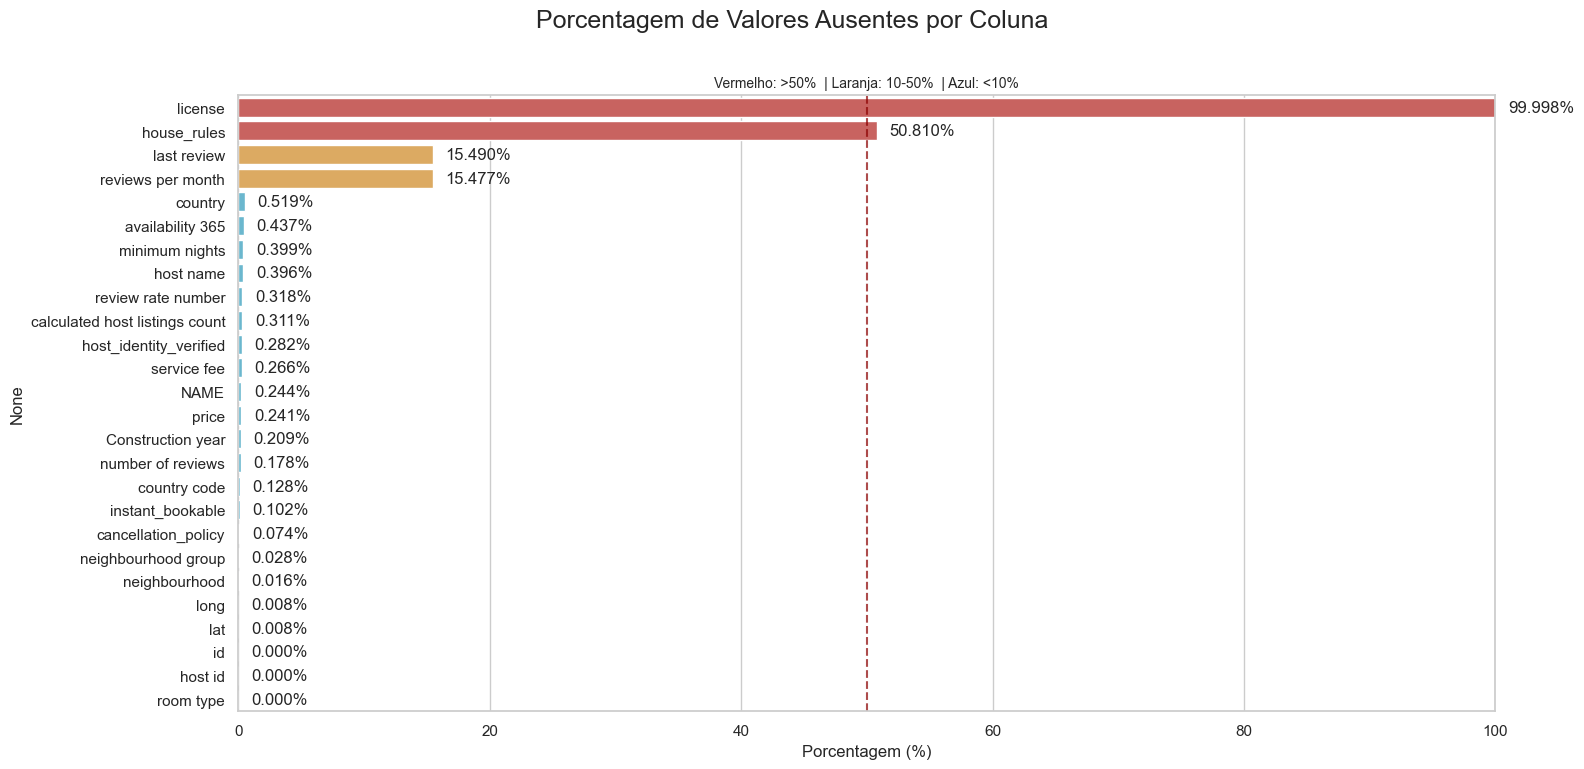

In [75]:
null_perc = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

colors = ['#d9534f' if v > 50 else '#f0ad4e' if v > 10 else '#5bc0de' for v in null_perc.values]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 8))
ax = sns.barplot(x=null_perc.values, y=null_perc.index, hue=null_perc.index, palette=colors, legend=False)

plt.suptitle("Porcentagem de Valores Ausentes por Coluna", fontsize=18, y=0.96)
ax.set_title("Vermelho: >50%  | Laranja: 10-50%  | Azul: <10%", fontsize=10)
ax.set_xlabel("Porcentagem (%)")
ax.set_xlim(0, 100)

for p in ax.patches:
    w = p.get_width()
    ax.text(w + 1, p.get_y() + p.get_height()/2, f'{w:.3f}%', va='center')

ax.axvline(50, color='darkred', linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Observemos algumas colunas com dados interessantes: 

- **license**: A coluna license tem apenas 2 registros que não vem com valor nulo. Todos os outros são nulos. O que torna esse campo tão importante? Por que a esmagadora maioria não precisa de uma licensa? E por que especificamente 2 anúncios tem? Existe algo que torna esses anúncios diferentes dos demais?
- **house_rules**: A coluna house_rules tem quase metade dos seus valores como nulos. Ou seja: metade dos aluguéis não vêm com regras explícitas.
- **last review**: mais de 80% dos anúncios teve pelo menos uma avaliação.
- **country** e **country code**: embora saibamos que os dados se referem sempre à cidade de Nova York, ainda assim existem registros que não indicam que o país do anúncio é os Estados Unidos.
- **id** e **name**: nenhum dos registros não tem identificador. No entanto, ainda existem registros que não tem nome (embora sejam de quantidade quase desprezível). O que levanta a pergunta: o site do airbnb permitiu anúncios sem nome? Ou houve falha no momento da extração dos dados?
- **long**, **lat**, **neighbourhood** e **neighbourhood group**: apenas 8 registros não tem latitude e longitude, mas o dobro de registros não pertence a nenhum bairro, e quase o triplo não pertence a nenhum grupo de bairro. Isso é importante porque `neighbourhood` e `neighbourhood group` são gerados a partir dos valores de latitude e longitude. Se apenas 8 registros não têm esses valores, por que 16 não tem bairro definido e 29 não tem um grupo de bairro definido?
- **price**: pouquíssimos registros não tem um preço definido. Como alguém faria um aluguel sem saber por quanto seria?

#### Distribuição de dados ausentes

O gráfico de barras nos deu um resumo da quantidade de dados ausentes em cada coluna. Agora, para entender a distribuição e os padrões desses valores nulos ao longo do dataset, o mapa de calor (heatmap) a seguir é muito bom para essa tarefa. Ele nos oferece uma representação visual de todo o conjunto de dados, onde as linhas mais claras indicam um dado faltante.

Essa visualização é valiosa porque nos ajuda a identificar se a ausência de dados é aleatória ou se há correlações. Por exemplo, podemos verificar se os dados faltantes em uma coluna coincidem com os de outra, o que pode revelar problemas estruturais nos registros e guiar uma estratégia de limpeza.

<Axes: >

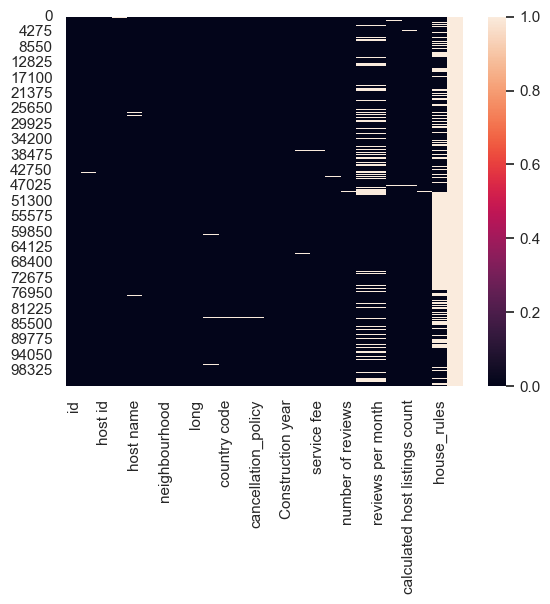

In [76]:
sns.heatmap(df.isnull())

### 2.5.2 Identificação de Registros Duplicados

#### Total de tuplas com id's duplicados

Após investigarmos a fundo os dados ausentes, o próximo passo na etapa de limpeza é verificar a existência de registros duplicados. Entradas repetidas podem contaminar a análise, distorcendo métricas, estatísticas e os resultados de qualquer modelo que venha a ser construído.

O código a seguir fará uma varredura em todo o conjunto de dados para identificar e contar quantas linhas são cópias exatas de outras. Este é um diagnóstico importante para garantir que cada registro em nossa análise seja único e represente uma observação distinta.

In [77]:
total = len(df)
dups = df.duplicated().sum()

print(f"Total de linhas: {total}")
print(f"Total de duplicadas: {dups}")

Total de linhas: 102599
Total de duplicadas: 541


#### Amostra das tuplas duplicadas

Após confirmarmos a existência de centenas de registros duplicados, é uma boa prática inspecionar uma amostra deles antes de tomar qualquer ação, como a remoção. Queremos entender a natureza dessas duplicatas para garantir que estamos tratando o problema corretamente.

O código a seguir realiza uma análise mais profunda, ele agrupa as linhas que são idênticas em todas as colunas, exceto pelo id, e nos mostra quais são elas. A tabela resultante exibirá os registros repetidos, a quantidade de vezes que eles aparecem (ocorrencias), e a lista de ids diferentes associados a cada um.

Amostra das linhas duplicadas, indicando a quantidade de ocorrências, os respectivos IDs duplicados e as posições correspondentes no dataset original:

In [78]:
resumo = (
    df.groupby([c for c in df.columns if c != "id"], dropna=False)
      .agg(ids=("id", list),
           ocorrencias=("id", "size"),
           posicoes=("id", lambda s: list(s.index)))
      .reset_index()
      .query("ocorrencias > 1")
      .sort_values("ocorrencias", ascending=False)
)

resumo = resumo[["ids","NAME","ocorrencias","posicoes"] + 
                [c for c in resumo.columns if c not in ["ids","NAME","ocorrencias","posicoes"]]]
resumo

,ids,NAME,ocorrencias,posicoes,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
101175,"[6064822, 6064822]",♡Private Rm/Women's Safe Art Home♡,2,"[9168, 102544]",27646270360,unconfirmed,Sarah,Brooklyn,Bedford-Stuyvesant,40.684110,...,$124,1.0,4.0,10/7/2015,0.08,3.0,3.0,38.0,No Smoking No Pets,NaN
109,"[20405844, 20405844]","""In the Clouds"" Brooklyn Heights Studio",2,"[35134, 102464]",7007990163,verified,Jenna,Brooklyn,Brooklyn Heights,40.695030,...,$61,8.0,1.0,9/27/2018,0.10,3.0,1.0,207.0,No Smoking and No Pets,NaN
184,"[35537207, 35537207]",# 2 One Lexury Bedroom close to JFK AIRPORT,2,"[62531, 102113]",12648350548,verified,Gelen,Queens,Springfield Gardens,40.664089,...,$189,3.0,9.0,11/10/2021,0.80,5.0,5.0,365.0,NaN,NaN
304,"[35596856, 35596856]",#510 Furnished studio in the heart of Manhattan,2,"[62639, 102221]",22417870465,verified,Best Inns USA,Manhattan,Gramercy,40.733810,...,$128,30.0,1.0,11/6/2021,0.25,5.0,20.0,124.0,NaN,NaN
558,"[35598513, 35598513]",****THE SUITE LIFE DUPLEX****,2,"[62642, 102224]",2578777349,verified,Kila,Brooklyn,Bedford-Stuyvesant,40.689760,...,$189,7.0,68.0,11/5/2021,1.01,2.0,2.0,175.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4721,"[35534998, 35534998]",2BR steps from Bell Blvd and Bayside Train Sta...,2,"[62527, 102109]",73016411582,verified,Noelle,Queens,Bayside,40.763170,...,$98,30.0,13.0,11/10/2021,0.43,2.0,4.0,349.0,NaN,NaN
4828,"[13978177, 13978177]",2bed Williamsburg Loft w Roof Access + City Views,2,"[23496, 102257]",2151054051,unconfirmed,Ashley,Brooklyn,Williamsburg,40.720590,...,$108,NaN,42.0,11/4/2018,1.71,1.0,1.0,0.0,No Smoking No Pets,NaN
5381,"[6044940, 6044940]",3BR Gramercy Apt in heart of NYC,2,"[9132, 102508]",59749079462,verified,Alissa,Manhattan,Kips Bay,40.739120,...,$85,1.0,0.0,NaN,NaN,5.0,1.0,368.0,"We only ask that you have a ton of fun, and th...",NaN
5414,"[6091333, 6091333]",3BR/1 Ba in TriBeCa w/ outdoor deck,2,"[9216, 102592]",53266862889,unconfirmed,Nick,Manhattan,Tribeca,40.718450,...,$157,1.0,0.0,NaN,NaN,2.0,1.0,177.0,Guests should treat my home as if it were thei...,NaN


#### Proporção entre duplicados e únicos:

Agora que identificamos o número absoluto de duplicatas e inspecionamos uma amostra, o próximo passo de diagnóstico é colocar esse número em perspectiva. Esse gráfico vai mostrar qual é o real impacto desses registros no volume total de dados.

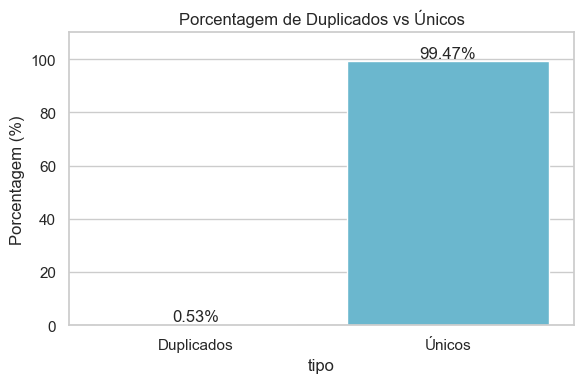

In [79]:
total = len(df)
dups = df.duplicated().sum()
stats = pd.DataFrame({
    "tipo": ["Duplicados", "Únicos"],
    "porcentagem": pd.Series([dups, total - dups]) / total * 100
})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=stats,
    x="tipo", y="porcentagem",
    hue="tipo", palette=["#d9534f", "#5bc0de"],
    legend=False
)

for p in ax.patches:
    h = p.get_height()
    ax.text(p.get_x()+p.get_width()/2, h+1, f"{h:.2f}%", ha="center")

ax.set_title("Porcentagem de Duplicados vs Únicos")
ax.set_ylabel("Porcentagem (%)")
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

#### Distribuição das duplicadas:

Já estabelecemos a quantidade e a proporção dos registros duplicados. Uma pergunta que podemos fazer nesta fase é sobre a sua distribuição, será que essas linhas repetidas estão concentradas em alguma parte específica do dataset ou estão espalhadas de forma aleatória?

Para investigar isso, o código a seguir irá gerar um gráfico de distribuição. Cada ponto no gráfico representará uma linha do nosso dataset, colorida de acordo com seu status: azul para registros únicos e vermelho para duplicados.

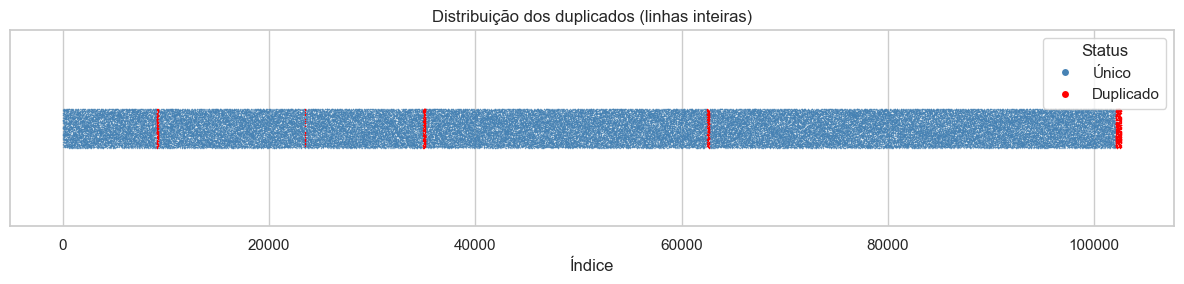

In [80]:
alpha_unico, size_unico = 0.5, 1
alpha_dup, size_dup = 1, 1

plot_df = pd.DataFrame({
    "Índice": df.index,
    "Duplicado": df.duplicated(keep=False).map({True: "Duplicado", False: "Único"})
})

fig, ax = plt.subplots(figsize=(12, 3))
sns.stripplot(data=plot_df[plot_df.Duplicado=="Único"],x="Índice",y=[""]*plot_df.Duplicado.eq("Único").sum(),
              color="steelblue",alpha=alpha_unico,size=size_unico,ax=ax)
sns.stripplot(data=plot_df[plot_df.Duplicado=="Duplicado"],x="Índice",y=[""]*plot_df.Duplicado.eq("Duplicado").sum(),
              color="red",alpha=alpha_dup,size=size_dup,ax=ax)

legend_elements=[Line2D([0],[0],marker='o',color='w',label='Único',markerfacecolor='steelblue',markersize=6),
                 Line2D([0],[0],marker='o',color='w',label='Duplicado',markerfacecolor='red',markersize=6)]
ax.legend(handles=legend_elements,title="Status",loc="upper right")

plt.title("Distribuição dos duplicados (linhas inteiras)")
plt.xlabel("Índice");plt.ylabel("")
plt.tight_layout();plt.show()

### 2.5.3 Resumo Estatístico Descritivo das Colunas

Após a verificação estrutural de dados ausentes e duplicados, a próxima etapa da nossa análise é entender a distribuição e as propriedades estatísticas das nossas colunas numéricas. Isso é importante para identificar a dispersão dos dados, a presença de outliers e possíveis erros de registro que não são aparentes em uma simples visualização de tabela.

In [81]:
df.drop(columns=["id", "host id"]).describe()

,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,102591.000000,102591.000000,102385.000000,102190.000000,102416.000000,86720.000000,102273.000000,102280.000000,102151.000000
mean,40.728094,-73.949644,2012.487464,8.135845,27.483743,1.374022,3.279106,7.936605,141.133254
std,0.055857,0.049521,5.765556,30.553781,49.508954,1.746621,1.284657,32.218780,135.435024
min,40.499790,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,40.688740,-73.982580,2007.000000,2.000000,1.000000,0.220000,2.000000,1.000000,3.000000
50%,40.722290,-73.954440,2012.000000,3.000000,7.000000,0.740000,3.000000,1.000000,96.000000
75%,40.762760,-73.932350,2017.000000,5.000000,30.000000,2.000000,4.000000,2.000000,269.000000
max,40.916970,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


O comando **'df.describe()** é uma ferramenta de diagnóstico do pandas que gera um resumo estatístico de todas as colunas de um DataFrame, tanto as numéricas quanto as textuais. Ao aplicá-lo em nosso conjunto de dados, obtivemos um panorama da qualidade dos dados, o que nos permitiu identificar pontos candidatos para a etapa de limpeza (camada Silver).

Constatamos que colunas essenciais como **price** e **service fee** estão formatadas incorretamente como texto, e não como números. Além disso, a análise expôs erros claros, como um valor mínimo impossível de -10 para a coluna **availability_365**, e outliers em **minimum_nights**. Por fim, o resumo quantificou a alta incidência de dados ausentes em colunas como **last_review** e **house_rules**, fornecendo esses campos como indicados para a etapa de tratamento do dataset.

### 2.5.4 Problemas de Formato

Nossa análise, especialmente o resumo estatístico, revelou um ponto crítico de colunas que deveriam ser numéricas, como ```price``` e ```service fee```, não apareceram nos cálculos. Isso acontece porque elas foram interpretadas como texto (object).

Para corrigir esse problema, precisamos primeiro entender a causa. O código a seguir irá isolar essas duas colunas e exibir seus primeiros valores, além de confirmar seus tipos de dados. Essa inspeção visual nos permitirá identificar quais caracteres não numéricos estão impedindo a conversão e precisam ser removidos.

In [82]:
primeiros_valores = df[['price', 'service fee']].head()

print(primeiros_valores)

print("\nTipos de dados das colunas:")
print(df[['price', 'service fee']].dtypes)

   price service fee
0  $966        $193 
1  $142         $28 
2  $620        $124 
3  $368         $74 
4  $204         $41 

Tipos de dados das colunas:
price          object
service fee    object
dtype: object


### 2.5.5 Valores Inconsistentes (Outliers negativos)

Durante a análise do resumo estatístico (describe()), levantamos a suspeita sobre valores inconsistentes, como um mínimo negativo para a coluna availability_365. Valores negativos em campos que não podem ser negativos são erros de dados que precisam ser tratados.

Para investigar isso, o código a seguir fará uma varredura em todas as colunas numéricas para contar a ocorrência de valores negativos. 

In [83]:
df_numeric = df.select_dtypes(include=np.number)
contagem_negativos = (df_numeric < 0).sum()
colunas_e_contagem = contagem_negativos[contagem_negativos > 0]

print("Contagem de valores negativos por coluna:")
print(colunas_e_contagem)

Contagem de valores negativos por coluna:
long                102591
minimum nights          13
availability 365       432
dtype: int64


### Conclusão da Análise Exploratória e Próximos Passos

A fase de Análise Exploratória de Dados foi concluída, nos fornecendo um panorama sobre a estrutura, a qualidade e as características do nosso conjunto de dados. Através desta investigação, embora rico em informações, o dataset possui diversas inconsistências que precisam ser tratadas antes de qualquer análise aprofundada.

Os principais problemas identificados foram:

- Dados Ausentes: Uma alta porcentagem de valores nulos em colunas como license e house_rules.
- Dados Duplicados: A presença de 541 registros completamente idênticos.
- Problemas de Formato: Colunas financeiras cruciais (price, service fee) formatadas incorretamente como texto.
- Valores Inconsistentes: A existência de valores ilógicos, como minimum nights e availability_365 negativos, além de outliers extremos.

A conclusão desta etapa é que o dataset em seu estado bruto não é adequado para fazer uma análise confiável. Portanto, o próximo passo será focado na Limpeza, onde iremos executar um plano para corrigir cada um dos problemas levantados.